## 前処理01

本ファイルは以下の処理を行うコードである。

1. `/workspace/datasets/statcast`データセットの中で、打席で2000球以上を経験したバッターを抽出する。

2. それらのバッターのデータのみを抽出した新しいサブセットを作成し、`/workspace/datasets/statcast-customized/preprocess_01`に保存する。

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
save_root_path = '/workspace/datasets/statcast-customized-tmp/preprocess_01/'
load_root_path = '/workspace/datasets/statcast/'

In [3]:
def get_file_path_list(load_root_path):
    file_path_list = []
    # Walk through the directory and its subdirectories to find all CSV files
    for root, dirs, files in os.walk(load_root_path):
        for file in files:
            if file.endswith('.csv'):
                file_path_list.append(os.path.join(root, file))
    # Sort the file paths to ensure consistent order
    file_path_list.sort()
    return file_path_list

In [4]:
def load_csv(path: str) -> pd.DataFrame:
    """Read a CSV file and return a pandas DataFrame."""
    return pd.read_csv(path)

In [5]:
def get_unique_values_and_counts_from_column(column_name: str, csv_files: list) -> dict:
    """Get unique values and their counts from a specified column in a DataFrame."""
    value_counts = {}
    for file_path in csv_files:
        df = load_csv(file_path)
        counts = df[column_name].value_counts()
        for value, count in counts.items():
            if value in value_counts:
                value_counts[value] += count
            else:
                value_counts[value] = count
    return value_counts

In [6]:
csv_file_path_list = get_file_path_list(load_root_path)
for file_path in csv_file_path_list:
    print(f'Load: {file_path}')
print(f'Number of CSV files: {len(csv_file_path_list)}')

Load: /workspace/datasets/statcast/statcast_2017_04.csv
Load: /workspace/datasets/statcast/statcast_2017_05.csv
Load: /workspace/datasets/statcast/statcast_2017_06.csv
Load: /workspace/datasets/statcast/statcast_2017_07.csv
Load: /workspace/datasets/statcast/statcast_2017_08.csv
Load: /workspace/datasets/statcast/statcast_2017_09.csv
Load: /workspace/datasets/statcast/statcast_2017_10.csv
Load: /workspace/datasets/statcast/statcast_2017_11.csv
Load: /workspace/datasets/statcast/statcast_2018_03.csv
Load: /workspace/datasets/statcast/statcast_2018_04.csv
Load: /workspace/datasets/statcast/statcast_2018_05.csv
Load: /workspace/datasets/statcast/statcast_2018_06.csv
Load: /workspace/datasets/statcast/statcast_2018_07.csv
Load: /workspace/datasets/statcast/statcast_2018_08.csv
Load: /workspace/datasets/statcast/statcast_2018_09.csv
Load: /workspace/datasets/statcast/statcast_2018_10.csv
Load: /workspace/datasets/statcast/statcast_2019_03.csv
Load: /workspace/datasets/statcast/statcast_2019

In [7]:
unique_batters_all_files = get_unique_values_and_counts_from_column("batter", csv_file_path_list)
print(unique_batters_all_files)
print(f"Total unique batters across all files: {len(unique_batters_all_files)}")

{430832: 4717, 656941: 23300, 502671: 23607, 545361: 16228, 592178: 13193, 467793: 21812, 453568: 17107, 547180: 20767, 474832: 11747, 595281: 10982, 543685: 12814, 519346: 6069, 446334: 10991, 429665: 8402, 571976: 11192, 543543: 6959, 488862: 1357, 594809: 6792, 443558: 12992, 542340: 10551, 592206: 20730, 596115: 16515, 518934: 17396, 519306: 4119, 572041: 9981, 519203: 17101, 593934: 9407, 448602: 4163, 405395: 9760, 429664: 6205, 435079: 5774, 571740: 6953, 608070: 23649, 519048: 7197, 594777: 11256, 571448: 20120, 452254: 4577, 608369: 15997, 607680: 10947, 622534: 12664, 451594: 6604, 608577: 8948, 592518: 21591, 596019: 23609, 456715: 9714, 434158: 5848, 571875: 6695, 592885: 20965, 435063: 2144, 608336: 14167, 455976: 8350, 460086: 7500, 572114: 881, 621043: 18690, 400121: 3585, 434778: 5116, 514917: 14217, 519317: 16778, 476704: 8214, 572122: 10509, 501981: 8234, 553993: 22740, 608365: 4450, 430945: 6423, 452104: 2741, 460576: 3405, 518692: 23416, 446359: 3557, 474568: 5714, 

In [8]:
# unique_batters_all_filesの値の総和を計算する
total_balls_received = sum(unique_batters_all_files.values())
print(f"Batters who received at least 1 ball: {len(unique_batters_all_files)}, Total balls received by these batters: {total_balls_received}")

# unique_batters_all_filesにおいて、値が閾値以上のバッターを抽出してdictにする
threshold = 100  # 例: 100以上のボールを受けたバッターを抽出
unique_batters_above_threshold = {batter: count for batter, count in unique_batters_all_files.items() if count >= threshold}
total_balls_received_above_threshold = sum(unique_batters_above_threshold.values())
print(f"Batters who received {threshold} or more balls: {len(unique_batters_above_threshold)}, Total balls received by these batters: {total_balls_received_above_threshold}")

threshold = 1000  # 例: 1000以上のボールを受けたバッターを抽出
unique_batters_above_threshold = {batter: count for batter, count in unique_batters_all_files.items() if count >= threshold}
total_balls_received_above_threshold = sum(unique_batters_above_threshold.values())
print(f"Batters who received {threshold} or more balls: {len(unique_batters_above_threshold)}, Total balls received by these batters: {total_balls_received_above_threshold}")

threshold = 2000  # 例: 2000以上のボールを受けたバッターを抽出（規定打席に立った打者が1シーズンで経験する球数）
unique_batters_above_threshold = {batter: count for batter, count in unique_batters_all_files.items() if count >= threshold}
total_balls_received_above_threshold = sum(unique_batters_above_threshold.values())
print(f"Batters who received {threshold} or more balls: {len(unique_batters_above_threshold)}, Total balls received by these batters: {total_balls_received_above_threshold}")

threshold = 10000  # 例: 10000以上のボールを受けたバッターを抽出
unique_batters_above_threshold = {batter: count for batter, count in unique_batters_all_files.items() if count >= threshold}
total_balls_received_above_threshold = sum(unique_batters_above_threshold.values())
print(f"Batters who received {threshold} or more balls: {len(unique_batters_above_threshold)}, Total balls received by these batters: {total_balls_received_above_threshold}")

Batters who received at least 1 ball: 4161, Total balls received by these batters: 6360261
Batters who received 100 or more balls: 1616, Total balls received by these batters: 6315011
Batters who received 1000 or more balls: 972, Total balls received by these batters: 6047668
Batters who received 2000 or more balls: 783, Total balls received by these batters: 5781569
Batters who received 10000 or more balls: 189, Total balls received by these batters: 2815090


規定打席に立つ打者が１シーズンで対峙する投球数はおよそ2000球である。

2000球以上の投球と対峙した打者にデータを絞る。

In [9]:
threshold = 2000  # 例: 2000以上のボールを受けたバッターを抽出（規定打席に立った打者が1シーズンで経験する球数）
unique_batters_above_threshold = {batter: count for batter, count in unique_batters_all_files.items() if count >= threshold}
total_balls_received_above_threshold = sum(unique_batters_above_threshold.values())
print(f"Batters who received {threshold} or more balls: {len(unique_batters_above_threshold)}, Total balls received by these batters: {total_balls_received_above_threshold}")

Batters who received 2000 or more balls: 783, Total balls received by these batters: 5781569


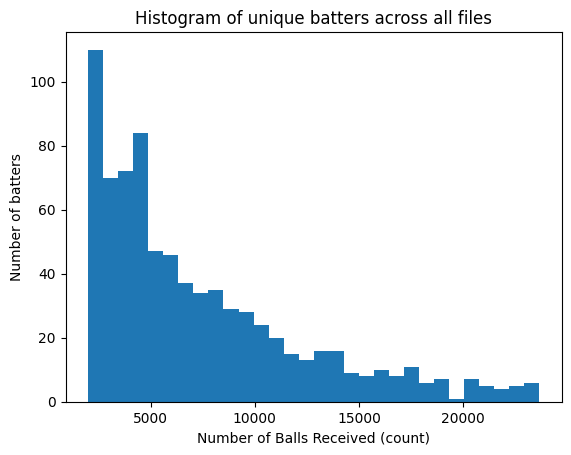

In [10]:
counts = pd.Series(unique_batters_above_threshold)
counts.plot.hist(bins=30)
plt.xlabel("Number of Balls Received (count)")
plt.ylabel("Number of batters")
plt.title("Histogram of unique batters across all files")
plt.show()

In [11]:
def save_filtered_dataset(batter_set: set, source_csv_path: str, save_dir_path: str):
    """Save the filtered DataFrame to a Parquet file."""
    # Load the original dataset
    df_original = load_csv(source_csv_path)
    df_filtered = df_original[df_original["batter"].isin(batter_set)].copy()

    # Save the filtered dataset to a new Parquet file
    save_file_name = source_csv_path.split("/")[-1].replace(".csv", ".parquet")
    save_path = f"{save_dir_path}/{save_file_name}"

    # Ensure the directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Save the filtered DataFrame to a Parquet file
    df_filtered.to_parquet(save_path, index=False)
    print(f"Saved filtered dataset: N original = {len(df_original)}, N filtered = {len(df_filtered)}, saved to: {save_path}")

In [12]:
# batter_setを作成する
batters_above_threshold = set(unique_batters_above_threshold.keys())
print(f"Number of batters above threshold: {len(batters_above_threshold)}")

Number of batters above threshold: 783


In [13]:
# 全てのCSVファイルに対してフィルタリングを適用して保存する
for i, csv_file_path in enumerate(csv_file_path_list):
    print(f"Processing file {i+1}/{len(csv_file_path_list)}: {csv_file_path}")
    save_filtered_dataset(batters_above_threshold, csv_file_path, save_root_path)

Processing file 1/72: /workspace/datasets/statcast/statcast_2017_04.csv
Saved filtered dataset: N original = 108785, N filtered = 89094, saved to: /workspace/datasets/statcast-customized-tmp/preprocess_01//statcast_2017_04.parquet
Processing file 2/72: /workspace/datasets/statcast/statcast_2017_05.csv
Saved filtered dataset: N original = 126719, N filtered = 103800, saved to: /workspace/datasets/statcast-customized-tmp/preprocess_01//statcast_2017_05.parquet
Processing file 3/72: /workspace/datasets/statcast/statcast_2017_06.csv
Saved filtered dataset: N original = 122153, N filtered = 102555, saved to: /workspace/datasets/statcast-customized-tmp/preprocess_01//statcast_2017_06.parquet
Processing file 4/72: /workspace/datasets/statcast/statcast_2017_07.csv
Saved filtered dataset: N original = 112890, N filtered = 96827, saved to: /workspace/datasets/statcast-customized-tmp/preprocess_01//statcast_2017_07.parquet
Processing file 5/72: /workspace/datasets/statcast/statcast_2017_08.csv
Sa